In [1]:
import sys
# here, either reference to satclip repo goes, or can try and create git submodule 🤷‍♀️ 
# https://github.com/microsoft/satclip/tree/main
sys.path.append('/home/cbutsko/Desktop/cbutsko_experiments/satclip/satclip')

# general
import numpy as np
import pandas as pd
import itertools
import gc
import re
import torch
import glob
import rioxarray
import xarray as xr

# modeling
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
# from sklearn.utils.validation import check_is_fitted, check_array
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# plotting and output
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from cbutsko_utils import plot_confusion_matrix
import warnings
warnings.filterwarnings(action='ignore')
tqdm.pandas()

# SatClip libs
from load import get_satclip
from cbutsko_utils import prepare_satclip_embeddings

# processing utils
from cbutsko_utils import patch2feats, process_raw_features_input_df

# hierarchical clsfc libs
from hiclass import LocalClassifierPerParentNode, LocalClassifierPerNode
from cbutsko_utils import CatBoostClassifierWrapper, LocalClassifierPerNodeWrapper, LocalClassifierPerParentNodeWrapper

In [2]:
# read files with mappings to crop names and hierarchy

label_columns = ['cropland', 'landcover', 'cropgroup']

wc2ec_map = pd.read_csv('wc2eurocrops_map.csv')
ec_map = pd.read_csv('eurocrops_map_wcr_edition.csv', index_col='ec_code')

In [3]:
# read parquet files, assign hierarchical labels and do small clean-up  
tpath = '/vitodata/worldcereal/features/features-presto-monthly-nointerp/annual_CIB/'

trn_df = process_raw_features_input_df(
    '{}CAL/training_df_LC.parquet'.format(tpath),
    wc2ec_map,
    ec_map,
    label_columns)
val_df = process_raw_features_input_df(
    '{}VAL/training_df_LC.parquet'.format(tpath),
    wc2ec_map,
    ec_map,
    label_columns)

### Couple of distributions of training data

<Axes: xlabel='cropgroup_name', ylabel='aez_zoneid'>

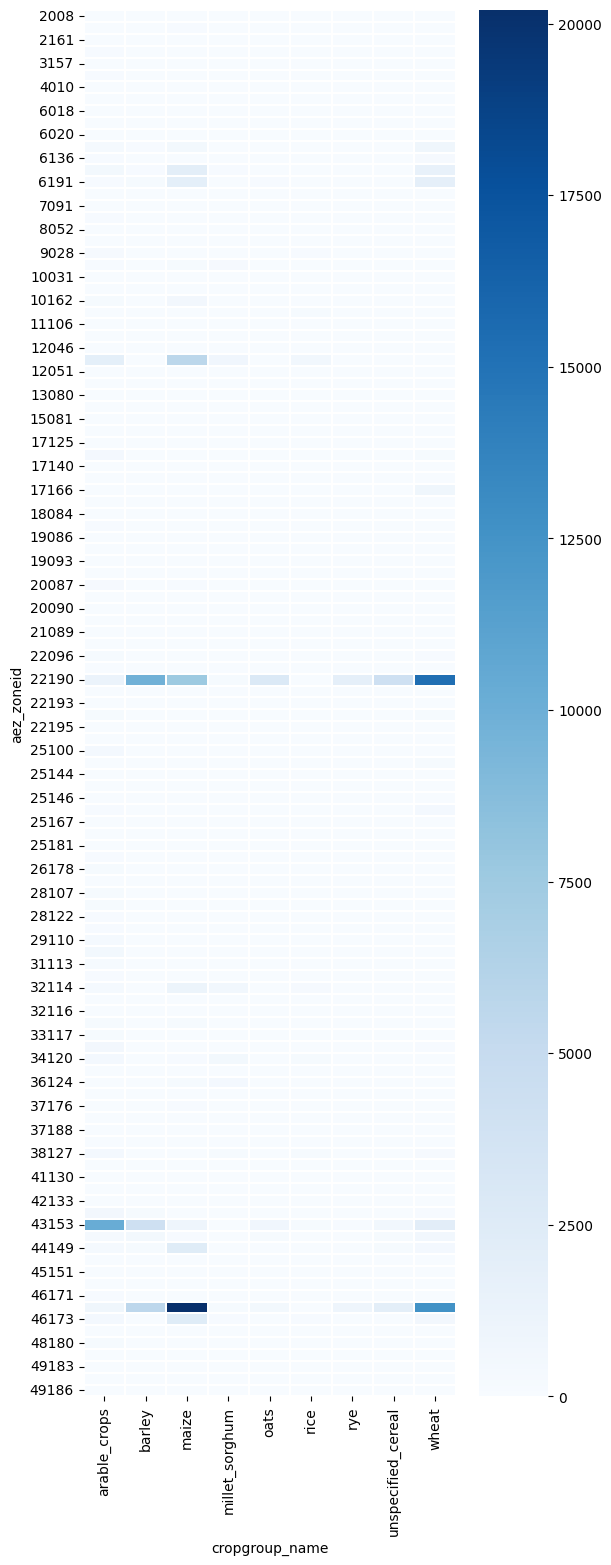

In [4]:
tdf = trn_df[['cropgroup_name','aez_zoneid']].value_counts().sort_index().reset_index()
tdf = tdf.pivot(index='aez_zoneid', columns='cropgroup_name', values='count')
tdf.fillna(0, inplace=True)
tdf.drop(columns=['not_crop','not_cereal'], inplace=True)
fig, ax = plt.subplots(figsize=(6,18))
sns.heatmap(ax=ax, data=tdf, cmap='Blues', linewidths=0.30, annot=False)

In [ ]:
tdf = trn_df[['aez_zoneid','valid_date']]
tdf['valid_date'] = tdf['valid_date'].dt.year 
tdf = tdf.value_counts().sort_index().reset_index()
tdf = tdf.pivot(index='aez_zoneid', columns='valid_date', values='count')
tdf.fillna(0, inplace=True)
fig, ax = plt.subplots(figsize=(5,25))
sns.heatmap(ax=ax, data=tdf, cmap='Blues', linewidths=0.30, annot=False)

In [ ]:
tdf = trn_df[['cropgroup_name','valid_date']]
tdf['valid_date'] = tdf['valid_date'].dt.year 
tdf = tdf[~tdf['cropgroup_name'].isin(['not_crop','not_cereal'])]
tdf = tdf.value_counts().sort_index().reset_index()
tdf = tdf.pivot(index='cropgroup_name', columns='valid_date', values='count')
tdf.fillna(0, inplace=True)
fig, ax = plt.subplots(figsize=(6,6))
sns.heatmap(ax=ax, data=tdf, cmap='Blues', linewidths=0.30, annot=True, fmt='n') 

### SatCLIP embeddings

1. Get the embeddings themselves for train/val/test samples

In [5]:
# again, here goes either path to a model, or git submodule can be created 🤷‍♀️
model_path = '/home/cbutsko/Desktop/cbutsko_experiments/satclip-resnet18-l10.ckpt'
model = get_satclip(model_path, device='cpu')
model.eval()

using pretrained moco resnet18


LocationEncoder(
  (posenc): SphericalHarmonics()
  (nnet): SirenNet(
    (layers): ModuleList(
      (0-1): 2 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
)

In [6]:
satclip_df_trn = prepare_satclip_embeddings(model, trn_df)
satclip_df_val = prepare_satclip_embeddings(model, val_df)

  0%|          | 0/84 [00:00<?, ?it/s]

  0%|          | 0/24 [00:00<?, ?it/s]

2. Fit PCA on (part of) train data

In [7]:
n_pcs = 32
pca_model = PCA(n_components=n_pcs)
n_rows = satclip_df_trn.shape[0]

scaler = StandardScaler()
scaler.fit(satclip_df_trn.values)
satclip_emb_trn_norm = scaler.transform(satclip_df_trn.values)
satclip_emb_val_norm = scaler.transform(satclip_df_val.values)

pca_model.fit(satclip_emb_trn_norm[np.random.randint(n_rows, size=int(0.7*n_rows)),:])

PCA(n_components=32)

In [ ]:
# basic check on variance captured
np.cumsum(pca_model.explained_variance_ratio_)

In [ ]:
# prepare dataframe to plot some of the features against first two PCs
satclip_pca_df_trn = pca_model.transform(satclip_emb_trn_norm)
pcs_plot_df = pd.DataFrame(satclip_pca_df_trn[:,:2], columns=['PC1','PC2'], index=satclip_df_trn.index)
pcs_plot_df[['cropland','aez_zoneid','cropgroup_name']] = trn_df[['cropland','aez_zoneid','cropgroup_name']]
pcs_plot_df['cropland'] = pcs_plot_df['cropland'].map({1: 'crops', 0: 'not_crops'})

In [ ]:
plt.figure()
plt.figure(figsize=(7,7))
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('PC1', fontsize=10)
plt.ylabel('PC2', fontsize=10)
targets = list(trn_df['aez_zoneid'].value_counts().iloc[:10].index)
colors = list(mcolors.TABLEAU_COLORS.values())
for ii,taez in enumerate(targets):
    tdf = pcs_plot_df[pcs_plot_df['aez_zoneid']==taez].sample(n=5000)
    plt.scatter(
        tdf['PC1'], 
        tdf['PC2'], 
        c=colors[ii], s=1)

plt.title('Location Embedding PCs vs AEZ, nointerp_V1_TRAIN, random 5k samples')
plt.legend(targets, prop={'size': 8}, title='AEZ id')

3. Transform train/val/test SatCLIP embeddings into PCs and append them to main dataframes

In [8]:
satclip_pca_colnames = ['satclip_PC{}'.format(jj) for jj in range(n_pcs)]

satclip_pca_trn = pca_model.transform(satclip_emb_trn_norm)
satclip_pca_df_trn= pd.DataFrame(
    satclip_pca_trn, 
    columns=satclip_pca_colnames, 
    index=satclip_df_trn.index)

satclip_pca_val = pca_model.transform(satclip_emb_val_norm)
satclip_pca_df_val= pd.DataFrame(
    satclip_pca_val, 
    columns=satclip_pca_colnames, 
    index=satclip_df_val.index)

trn_df = pd.concat([trn_df,satclip_pca_df_trn], join='inner', axis=1)
val_df = pd.concat([val_df,satclip_pca_df_val], join='inner', axis=1)

del satclip_pca_df_trn, satclip_pca_df_val
gc.collect()

18

### Get pre-computed Presto embedding and append them to main dataframes

In [9]:
presto_df_trn = pd.read_parquet('{}CAL/training_df_LC_presto-worldcereal.parquet'.format(tpath))
presto_df_val = pd.read_parquet('{}VAL/training_df_LC_presto-worldcereal.parquet'.format(tpath))

presto_df_trn.reset_index(inplace=True)
presto_df_val.reset_index(inplace=True)

presto_df_trn.set_index(['location_id','ref_id','pixelids'], inplace=True)
presto_df_val.set_index(['location_id','ref_id','pixelids'], inplace=True)

presto_emb_colnames = [xx for xx in presto_df_val.columns if 'presto_ft' in xx]

trn_df = pd.concat([trn_df,presto_df_trn[presto_emb_colnames]], join='inner', axis=1)
val_df = pd.concat([val_df,presto_df_val[presto_emb_colnames]], join='inner', axis=1)

del presto_df_trn, presto_df_val
gc.collect()

0

### Classification

In [10]:
# group feature names for easier use
n_months = 12

optical12_feats = [xx for xx in trn_df.columns if re.search(r'OPTICAL.*ts({})-'.format('|'.join(map(str, list(range(n_months))))), xx)]
sar12_feats = [xx for xx in trn_df.columns if re.search(r'SAR.*ts({})-'.format('|'.join(map(str, list(range(n_months))))), xx)]
temp12_feats  = [xx for xx in trn_df.columns if re.search(r'METEO-temp.*ts({})-'.format('|'.join(map(str, list(range(n_months))))), xx)]
prcp12_feats  = [xx for xx in trn_df.columns if re.search(r'METEO-precip.*ts({})-'.format('|'.join(map(str, list(range(n_months))))), xx)]
dem_feats = ['DEM-alt-20m', 'DEM-slo-20m']
latlon_feats = ['lat','lon']

optical_agg_feats = [xx for xx in trn_df.columns if ('OPTICAL' in xx) and ('12m_' in xx)]
sar_agg_feats = [xx for xx in trn_df.columns if ('SAR' in xx) and ('12m_' in xx)]
temp_agg_feats = [xx for xx in trn_df.columns if ('METEO-temperature' in xx) and ('12m_' in xx)]
prcp_agg_feats = [xx for xx in trn_df.columns if ('METEO-precipitation' in xx) and ('12m_' in xx)]

presto_emb_feats = [xx for xx in trn_df.columns if 'presto' in xx]
satclip_pca_feats = [xx for xx in trn_df.columns if 'satclip_PC' in xx]

In [ ]:
# Define features to use, label, year and/or AEZ to leave out
label_col = 'cropland_wc'
features_list = optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats
test_years = []
test_aezs = []

In [ ]:
# create train/val/test datasets based on variables above
X_trnval_df = trn_df[
    (~trn_df['end_date'].dt.year.isin(test_years)) & 
    (~trn_df['aez_zoneid'].isin(test_aezs))][features_list]
y_trnval_df = trn_df[
    (~trn_df['end_date'].dt.year.isin(test_years)) & 
    (~trn_df['aez_zoneid'].isin(test_aezs))][label_col]

# use the above dataframe to get a separate val set to detect overfitting
X_trn_df, X_val_df, y_trn_df, y_val_df = train_test_split(
    X_trnval_df, y_trnval_df,
    stratify=y_trnval_df,
    test_size=0.3)

# append unused years/AEZs to test set
X_tst_df = val_df[features_list]
X_trn_not_used = trn_df[
    (trn_df['end_date'].dt.year.isin(test_years)) | 
    (trn_df['aez_zoneid'].isin(test_aezs))][features_list].reset_index(drop=True)
X_tst_df = pd.concat([X_tst_df,X_trn_not_used], axis=0)

y_tst_df = val_df[label_col]
y_trn_not_used = trn_df[
    (trn_df['end_date'].dt.year.isin(test_years)) | 
    (trn_df['aez_zoneid'].isin(test_aezs))][label_col].reset_index(drop=True)
y_tst_df = pd.concat([y_tst_df,y_trn_not_used], axis=0)

In [ ]:
# initialize and train the model
model = CatBoostClassifier(
    iterations=5000, 
    depth=8,
    eval_metric='F1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
    )

model.fit(X_trn_df, y_trn_df, eval_set=Pool(X_val_df, y_val_df), early_stopping_rounds=200)
probs = model.predict_proba(X_tst_df)
pred = model.predict(X_tst_df).flatten()
if y_tst_df.nunique()==2:
    pred = np.array([xx=='True' for xx in pred])

In [ ]:
# create dataframe with predictions and useful attributes
preds_df = pd.DataFrame([y_tst_df.values, pred]).transpose()
preds_df.columns = ['true','pred']

for attr in ['aez_zoneid','end_date','CT_name','lat','lon']:
    preds_df[attr] = list(val_df[attr].values) + list(trn_df[
        (trn_df['end_date'].dt.year.isin(test_years)) | 
        (trn_df['aez_zoneid'].isin(test_aezs))][attr].values)

preds_df['year'] = preds_df['end_date'].dt.year

In [ ]:
preds_df.groupby('aez_zoneid').apply(lambda xx: pd.Series({
      'n_pixels': xx['aez_zoneid'].count(),
      'f1': f1_score(xx['true'], xx['pred'], pos_label=1)
  })).sort_values(by='n_pixels', ascending=False).iloc[:10]

### Spatial test

In [ ]:
# path to test patches
test_patches_path = '/home/cbutsko/Desktop/cbutsko_experiments/test_patches/'
test_patches_files = glob.glob('{}*.nc'.format(test_patches_path))

In [ ]:
patch_ind = 2

test_patch_fpath = test_patches_files[patch_ind]
test_patch = rioxarray.open_rasterio(
    test_patch_fpath, 
    decode_times=False)
# test_patch = test_patch.rio.reproject('EPSG:4326')

test_patch_rgb = np.dstack((
    test_patch.B04.values[0,:,:],
    test_patch.B03.values[0,:,:],
    test_patch.B02.values[0,:,:]))

test_patch_ndvi = (test_patch.B08.values[0,:,:] - test_patch.B04.values[0,:,:]) / (test_patch.B08.values[0,:,:] + test_patch.B04.values[0,:,:])
test_patch_fpath

In [ ]:
test_patch_df_feats = patch2feats(test_patch, features_list)

test_patch_probs = model.predict_proba(test_patch_df_feats)[:,1]
test_patch_pred = model.predict(test_patch_df_feats).flatten()
test_patch_pred = np.array([xx=='True' for xx in test_patch_pred])

In [ ]:
fig = plt.figure(figsize=(12,8))

fig.add_subplot(2, 3, 1)
plt.imshow(test_patch.worldcereal_cropland.values[0,:,:])
plt.title('WorldCereal Mask')

fig.add_subplot(2, 3, 2)
plt.imshow(test_patch_rgb, norm='linear')
plt.title('RGB')

fig.add_subplot(2, 3, 3)
plt.imshow(test_patch_ndvi)
plt.title('NDVI')

fig.add_subplot(2, 3, 4)
plt.imshow(test_patch_pred.reshape(test_patch['x'].shape[0], test_patch['y'].shape[0]))
plt.title('Raw Feat Prediction')

fig.add_subplot(2, 3, 5)
plt.imshow(test_patch_probs.reshape(test_patch['x'].shape[0], test_patch['y'].shape[0]))
plt.title('Raw Feat Probs')

### Hierarchical classification

In [11]:
features_list = optical12_feats + sar12_feats + temp12_feats + prcp12_feats + dem_feats
test_years = []
test_aezs = []

In [13]:
# pretend that crop/not_crop is solved
# this is also necessary, as now kernel keeps crashing on full dataset 😢
trn_df = trn_df[trn_df['cropland']==1]
val_df = val_df[val_df['cropland']==1]
label_columns = label_columns[1:]

In [15]:
# create train/val/test datasets based on variables above
X_trn_df = trn_df[
    (~trn_df['end_date'].dt.year.isin(test_years)) & 
    (~trn_df['aez_zoneid'].isin(test_aezs))][features_list]
y_trn_df = trn_df[
    (~trn_df['end_date'].dt.year.isin(test_years)) & 
    (~trn_df['aez_zoneid'].isin(test_aezs))][label_columns]

# no need to do splitting for val here, as it's happenning at inside at every level
# append unused years/AEZs to test set
X_tst_df = val_df[features_list]
X_trn_not_used = trn_df[
    (trn_df['end_date'].dt.year.isin(test_years)) | 
    (trn_df['aez_zoneid'].isin(test_aezs))][features_list].reset_index(drop=True)
X_tst_df = pd.concat([X_tst_df,X_trn_not_used], axis=0)

y_tst_df = val_df[label_columns]
y_trn_not_used = trn_df[
    (trn_df['end_date'].dt.year.isin(test_years)) | 
    (trn_df['aez_zoneid'].isin(test_aezs))][label_columns].reset_index(drop=True)
y_tst_df = pd.concat([y_tst_df,y_trn_not_used], axis=0)

In [16]:
# a look into hierarchy
y_tst_df.value_counts().sort_index()

landcover  cropgroup
1          1             7015
2          2            32297
1101       110100        2089
           110101       11139
           110102        5972
           110103         925
           110104        1348
           110106       13442
           110107        1118
           110108         626
Name: count, dtype: int64

In [17]:
cb_clsfr = CatBoostClassifierWrapper(
    iterations=1000, 
    depth=8,
    eval_metric='TotalF1',
    learning_rate=0.3,
    l2_leaf_reg=100,
    verbose=50,
    random_seed=42,
)

classifier = LocalClassifierPerParentNodeWrapper(
    local_classifier=cb_clsfr,
    n_jobs=-1,
)

classifier.fit(X_trn_df, y_trn_df)
pred, probs = classifier.predict_proba(X_tst_df)
pred = pred.astype('int32')

0:	learn: 0.5797657	test: 0.5834710	best: 0.5834710 (0)	total: 776ms	remaining: 12m 55s
50:	learn: 0.7330690	test: 0.7265162	best: 0.7265162 (50)	total: 36.5s	remaining: 11m 19s
100:	learn: 0.7673305	test: 0.7531343	best: 0.7531343 (100)	total: 1m 12s	remaining: 10m 47s
150:	learn: 0.7888241	test: 0.7669013	best: 0.7669125 (149)	total: 1m 48s	remaining: 10m 8s
200:	learn: 0.8071601	test: 0.7779015	best: 0.7779015 (200)	total: 2m 24s	remaining: 9m 35s
250:	learn: 0.8204183	test: 0.7852216	best: 0.7852216 (250)	total: 3m 1s	remaining: 9m
300:	learn: 0.8310224	test: 0.7889324	best: 0.7889324 (300)	total: 3m 37s	remaining: 8m 25s
350:	learn: 0.8411333	test: 0.7933046	best: 0.7933118 (349)	total: 4m 12s	remaining: 7m 47s
400:	learn: 0.8504113	test: 0.7965115	best: 0.7967846 (390)	total: 4m 48s	remaining: 7m 11s
450:	learn: 0.8582274	test: 0.7999570	best: 0.7999570 (450)	total: 5m 24s	remaining: 6m 35s
500:	learn: 0.8656215	test: 0.8022555	best: 0.8022555 (500)	total: 6m	remaining: 5m 59s
55

In [18]:
# compare predictions at a level
level_ind = -1

level_true = y_tst_df[label_columns[level_ind]]
level_pred = pred[:,level_ind]

# map to human names
tmap = ec_map[['{}_label'.format(label_columns[level_ind]),'{}_name'.format(label_columns[level_ind])]].drop_duplicates()
tmap = dict(tmap.to_numpy())
level_true = level_true.map(tmap)
level_pred = [*map(tmap.get, level_pred)]

In [19]:
print(classification_report(
    level_true, 
    level_pred, 
    target_names=np.sort(level_true.unique()))) 

                    precision    recall  f1-score   support

      arable_crops       0.90      0.88      0.89      7015
            barley       0.62      0.66      0.64      5972
             maize       0.81      0.81      0.81     13442
    millet_sorghum       0.65      0.46      0.54      1118
        not_cereal       0.85      0.85      0.85     32297
              oats       0.44      0.23      0.30      1348
              rice       0.80      0.72      0.76       626
               rye       0.60      0.30      0.40       925
unspecified_cereal       0.50      0.36      0.42      2089
             wheat       0.70      0.81      0.75     11139

          accuracy                           0.79     75971
         macro avg       0.69      0.61      0.64     75971
      weighted avg       0.79      0.79      0.79     75971



In [20]:
cm = confusion_matrix(level_true, level_pred)
plot_confusion_matrix(cm, np.unique(level_true))

NameError: name 'plt' is not defined

**Using probabilities to train a simple meta learner**

In [29]:
_, probs_trn = classifier.predict_proba(X_trn_df)
_, probs_tst = classifier.predict_proba(X_tst_df)

probs_features_trn = np.concatenate((
    probs_trn['l0'],
    probs_trn['l1']['1101']), axis=1)
probs_features_tst = np.concatenate((
    probs_tst['l0'], 
    probs_tst['l1']['1101']), axis=1)

In [34]:
logreg_meta_learner_probs_model = LogisticRegression(random_state=42).fit(
    probs_features_trn, 
    y_trn_df[label_columns[-1]].values)

logreg_meta_learner_pred = logreg_meta_learner_probs_model.predict(probs_features_tst) 
tmap = ec_map[['{}_label'.format(label_columns[-1]),'{}_name'.format(label_columns[-1])]].drop_duplicates()
tmap = dict(tmap.to_numpy())
logreg_meta_learner_pred = [*map(tmap.get, logreg_meta_learner_pred)]

In [71]:
print(classification_report(
    level_true, 
    logreg_meta_learner_pred, 
    target_names=np.sort(level_true.unique())))

                    precision    recall  f1-score   support

      arable_crops       0.90      0.88      0.89      7015
            barley       0.66      0.64      0.65      5972
             maize       0.85      0.79      0.82     13442
    millet_sorghum       0.68      0.45      0.54      1118
        not_cereal       0.82      0.89      0.85     32297
              oats       0.45      0.27      0.33      1348
              rice       0.83      0.70      0.76       626
               rye       0.59      0.33      0.42       925
unspecified_cereal       0.51      0.36      0.42      2089
             wheat       0.74      0.78      0.76     11139

          accuracy                           0.80     75971
         macro avg       0.70      0.61      0.64     75971
      weighted avg       0.79      0.80      0.79     75971



In [43]:
preds_df = pd.DataFrame([level_true.values, level_pred, logreg_meta_learner_pred]).transpose()
preds_df.columns = ['true','hiclass_pred','logreg_meta_pred']

In [65]:
crops_lst = ['arable_crops', 'not_cereal', 'cereals', 'unspecified_cereal', 'wheat', 'barley', 'rye', 'oats', 'maize', 'millet_sorghum', 'rice']
ii = 442
['{}: {}'.format(ii,jj) for ii, jj in zip(crops_lst, np.round(probs_features_tst[ii,:], 2))]

['arable_crops: 0.0',
 'not_cereal: 0.43',
 'cereals: 0.57',
 'unspecified_cereal: 0.05',
 'wheat: 0.13',
 'barley: 0.07',
 'rye: 0.0',
 'oats: 0.01',
 'maize: 0.73',
 'millet_sorghum: 0.0',
 'rice: 0.0']

In [70]:
preds_df[
    (preds_df['hiclass_pred']==preds_df['true']) &
    (preds_df['logreg_meta_pred']!=preds_df['true'])
    ][['true','logreg_meta_pred']].value_counts().sort_index()

true                logreg_meta_pred  
arable_crops        not_cereal             56
barley              arable_crops            1
                    not_cereal            120
                    oats                   14
                    rye                     3
                    unspecified_cereal     17
                    wheat                   3
maize               arable_crops            4
                    barley                  3
                    millet_sorghum          2
                    not_cereal            225
                    oats                    2
                    rye                     1
                    wheat                   8
millet_sorghum      not_cereal             16
oats                arable_crops            1
                    not_cereal             19
rice                millet_sorghum          1
                    not_cereal              8
                    wheat                   3
rye                 not_cereal           